# Healthcare Claims Data Science - Python Tutorial

**A practical, end-to-end guide for data scientists working with healthcare claims data, patient classification systems, and financial risk modeling.**

---

## How to Use This Tutorial

Work through the three notebooks **in order**. Each part builds on the previous:

| Part | Notebook | Focus |
|---|---|---|
| **Part 1** | `patient_classification_tools.ipynb` | Foundations — coding systems & classification tools |
| **Part 2** | `ds_responsibilities_claims_classification.ipynb` | DS Role — responsibilities & analytical frameworks |
| **Part 3** | `healthcare_claims_workflow.ipynb` | Implementation — full Python pipeline |

---

## Learning Path

```
START HERE
   │
   ▼
┌─────────────────────────────────────────────────────────────┐
│  PART 1 — patient_classification_tools.ipynb                │
│  • What is claims data and how does it flow?                │
│  • ICD-10, CPT, HCPCS, DRG, HCC, APR-DRG                  │
│  • Charlson Comorbidity Index (Python implementation)       │
│  • LACE Index for 30-day readmission risk                   │
│  • Visualizations: severity charts, risk distributions      │
└─────────────────────────────────────────────────────────────┘
   │
   ▼
┌─────────────────────────────────────────────────────────────┐
│  PART 2 — ds_responsibilities_claims_classification.ipynb   │
│  • Data acquisition, cleaning & feature engineering         │
│  • Risk stratification & disease registries                 │
│  • Financial risk model design                              │
│  • Value-based care (ACO, HEDIS, shared savings)           │
│  • Stakeholder collaboration framework                      │
└─────────────────────────────────────────────────────────────┘
   │
   ▼
┌─────────────────────────────────────────────────────────────┐
│  PART 3 — healthcare_claims_workflow.ipynb                  │
│  • Simulate realistic claims & eligibility data             │
│  • Clean and validate raw claims                            │
│  • Engineer PMPM, HCC score, CCI, utilization features     │
│  • 4-tier risk stratification + disease registries          │
│  • Train Linear, Random Forest, Gradient Boosting models    │
│  • ACO analytics & shared savings calculation               │
│  • HEDIS-like quality measures & care gap analysis          │
│  • 12-panel executive dashboard                             │
│  • Leadership KPI summary report                            │
└─────────────────────────────────────────────────────────────┘
```

---

## Prerequisites Check

Run the cell below to verify all required libraries are installed.

In [1]:
import importlib

required = {
    'pandas':       'Data manipulation',
    'numpy':        'Numerical computing',
    'matplotlib':   'Plotting & visualizations',
    'seaborn':      'Statistical visualizations',
    'sklearn':      'Machine learning models',
}

print(f"{'Library':<15} {'Version':<12} {'Purpose'}")
print('-' * 55)
all_ok = True
for pkg, purpose in required.items():
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, '__version__', 'n/a')
        print(f"  {pkg:<13} {version:<12} {purpose}")
    except ImportError:
        print(f"  {'MISSING':<13} {'--':<12} {purpose}  <-- run: pip install {pkg}")
        all_ok = False

print()
if all_ok:
    print("All dependencies satisfied. Ready to begin!")
else:
    print("Install missing packages:  pip install -r requirements.txt")

Library         Version      Purpose
-------------------------------------------------------
  pandas        2.3.3        Data manipulation
  numpy         2.2.6        Numerical computing
  matplotlib    3.10.0       Plotting & visualizations
  seaborn       0.13.2       Statistical visualizations
  sklearn       1.8.0        Machine learning models

All dependencies satisfied. Ready to begin!


---

## Quick Domain Reference

Run the cell below for a printable cheat-sheet of the core coding systems and metrics you will encounter across all three notebooks.

### Clinical Coding

Clinical coding systems are standardized tools used in healthcare to classify diagnoses, procedures, and medical services.
These codes ensure consistent documentation, billing, analysis, and reporting across different healthcare settings.

Key coding systems include:
- **ICD-10:** Captures diagnoses for all patient settings.
- **CPT & HCPCS:** Used for outpatient procedures, supplies, and services.
- **MS-DRG/APR-DRG/APC:** Group hospital stays or outpatient visits for payment and quality benchmarking.
- **HCC:** Supports risk adjustment in Medicare Advantage, affecting funding and care management.
- **Specialty Indices (CCI, LACE, DSM-5):** Measure comorbidity, readmission risk, or mental health diagnoses.

Accurate clinical coding is essential for patient care, actuarial modeling, reimbursement, and research.

In [2]:
import pandas as pd

# ── Clinical Coding Systems ────────────────────────────────────────────────
coding_systems = pd.DataFrame([
    ('ICD-10',       'All settings',         'Diagnosis coding',              'WHO'),
    ('CPT',          'Outpatient',            'Procedure billing',             'AMA'),
    ('HCPCS',        'Medicare/Medicaid',     'Supplies, drugs, equipment',    'CMS'),
    ('MS-DRG',       'Inpatient hospital',    'Hospital payment grouping',     'CMS'),
    ('HCC',          'Medicare Advantage',    'Risk adjustment / capitation',  'CMS'),
    ('APR-DRG',      'Inpatient',            'Severity of illness scoring',   '3M / CMS'),
    ('APC',          'Outpatient hospital',   'Outpatient payment grouping',   'CMS'),
    ('RUG / PDPM',   'Skilled nursing',       'Post-acute care payment',       'CMS'),
    ('OASIS / PDGM', 'Home health',           'Home care payment',             'CMS'),
    ('DSM-5',        'Mental health',         'Psychiatric diagnosis',         'APA'),
    ('CCI',          'All settings',          '10-year mortality predictor',   'Academic'),
    ('LACE',         'Post-inpatient',        '30-day readmission risk',       'Academic'),
], columns=['Code_System', 'Setting', 'Purpose', 'Governing_Body'])

print("Clinical Coding & Classification Systems")
print("=" * 72)
print(coding_systems.to_string(index=False))

Clinical Coding & Classification Systems
 Code_System             Setting                      Purpose Governing_Body
      ICD-10        All settings             Diagnosis coding            WHO
         CPT          Outpatient            Procedure billing            AMA
       HCPCS   Medicare/Medicaid   Supplies, drugs, equipment            CMS
      MS-DRG  Inpatient hospital    Hospital payment grouping            CMS
         HCC  Medicare Advantage Risk adjustment / capitation            CMS
     APR-DRG           Inpatient  Severity of illness scoring       3M / CMS
         APC Outpatient hospital  Outpatient payment grouping            CMS
  RUG / PDPM     Skilled nursing      Post-acute care payment            CMS
OASIS / PDGM         Home health            Home care payment            CMS
       DSM-5       Mental health        Psychiatric diagnosis            APA
         CCI        All settings  10-year mortality predictor       Academic
        LACE      Post-inpatient   

### Key Actuarial Metrics

In healthcare data science, actuarial metrics provide standardized ways to evaluate population health, cost, and risk. 
These metrics are critical for setting budgets, assessing risk, and evaluating the performance of healthcare plans. 
Some of the most important actuarial metrics include:

- **PMPM (Per Member Per Month):** The average cost incurred for each enrolled member per month.
- **HCC Risk Score:** A risk adjustment score predicting a person's expected healthcare costs relative to an average population.
- **CCI Score (Charlson Comorbidity Index):** Measures the burden of comorbidities to predict long-term mortality risk.
- **LACE Index:** Predicts the likelihood of hospital readmission within 30 days based on several clinical factors.
- **MLR (Medical Loss Ratio):** The proportion of premium revenue spent on medical care, indicating plan efficiency.
- **ER Rate/1000 & IP Rate/1000:** Frequency of emergency room visits and inpatient admissions per thousand members, showing utilization trends.
- **Risk-Adjusted Benchmark:** Target spending level aligned to the population's risk profile, used for performance comparisons.
- **Shared Savings:** Amount given back to providers or organizations for reducing costs below a set threshold while maintaining quality.

Understanding and using these metrics is foundational for data scientists and analysts working with healthcare claims and value-based care programs.

# ## Key Actuarial Metrics
# 
# **PMPM (Per Member Per Month cost):** Measures the average healthcare cost incurred for each enrolled member per month. Formula: `total_paid / enroll_months`
# 
# **HCC Risk Score:** A normalized score reflecting a member's predicted healthcare costs based on medical conditions and demographics. A value of 1.0 indicates risk equivalent to the national average. Formula: `age_gender_factor + sum(condition_weights)`
# 
# **CCI Score (Charlson Comorbidity Index):** Summarizes the risk posed by a member's comorbidities, predicting 10-year mortality. Higher scores indicate greater risk. Formula: `sum of weighted condition scores`
# 
# **LACE Index:** Predicts a patient's 30-day readmission risk using Length of stay (LOS), acuity, comorbidity, and emergency department visits. A score of 10 or higher signals high risk. Formula: `LOS + acuity + CCI + ER_visits`
# 
# **MLR (Medical Loss Ratio):** Evaluates the proportion of premium revenues spent on clinical services and claims, an indicator of plan efficiency. Formula: `claims_paid / premiums_collected`
# 
# **ER Rate/1000:** Tracks the frequency of emergency department visits per 1,000 members, indicating population health and access issues. Formula: `er_visits / members * 1000`
# 
# **IP Rate/1000:** Measures inpatient admissions per 1,000 members, providing insights into hospitalization rates. Formula: `ip_admits / members * 1000`
# 
# **Risk-Adjusted Benchmark:** Sets a spending target by adjusting per-member costs by average risk scores, used to evaluate cost efficiency. Formula: `national_avg_pmpm × avg_hcc_score`
# 
# **Shared Savings:** Quantifies the amount paid out to an Accountable Care Organization (ACO) if actual spending falls below a savings threshold. Formula: `savings_pmpm × 50% × 12 × member_count`



In [6]:
# ── Key Actuarial Metrics ──────────────────────────────────────────────────
metrics = pd.DataFrame([
    ('PMPM',            'Per Member Per Month cost',
     'total_paid / enroll_months'),
    ('HCC Risk Score',  'Normalized cost risk (1.0 = national avg)',
     'age_gender_factor + sum(condition_weights)'),
    ('CCI Score',       'Charlson Comorbidity Index',
     'sum of weighted condition scores'),
    ('LACE Index',      '30-day readmission risk (≥10 = high)',
     'LOS + acuity + CCI + ER_visits'),
    ('MLR',             'Medical Loss Ratio',
     'claims_paid / premiums_collected'),
    ('ER ate/1000',    'Emergency visits per 1,000 members',
     'er_visits / members * 1000'),
    ('IP RaRte/1000',    'Inpatient admits per 1,000 members',
     'ip_admits / members * 1000'),
    ('Risk-Adj Bench',  'Risk-adjusted expenditure benchmark',
     'national_avg_pmpm × avg_hcc_score'),
    ('Shared Savings',  'ACO savings payout (if savings_pct > MSR)',
     'savings_pmpm × 50% × 12 × member_count'),
], columns=['Metric', 'Description', 'Formula'])

print("\nKey Actuarial & Analytics Metrics")
print("=" * 72)
print(metrics.to_string(index=False))


Key Actuarial & Analytics Metrics
        Metric                               Description                                    Formula
          PMPM                 Per Member Per Month cost                 total_paid / enroll_months
HCC Risk Score Normalized cost risk (1.0 = national avg) age_gender_factor + sum(condition_weights)
     CCI Score                Charlson Comorbidity Index           sum of weighted condition scores
    LACE Index      30-day readmission risk (≥10 = high)             LOS + acuity + CCI + ER_visits
           MLR                        Medical Loss Ratio           claims_paid / premiums_collected
   ER ate/1000        Emergency visits per 1,000 members                 er_visits / members * 1000
 IP RaRte/1000        Inpatient admits per 1,000 members                 ip_admits / members * 1000
Risk-Adj Bench       Risk-adjusted expenditure benchmark          national_avg_pmpm × avg_hcc_score
Shared Savings ACO savings payout (if savings_pct > MSR)     savi

### Risk Tier Framework

The Risk Tier Framework is a method used to segment a patient population based on their predicted clinical risk and resource utilization. By assigning each patient to a tier, care teams can prioritize interventions, allocate resources effectively, and focus more attention on those most likely to benefit from intensive care management.

**How It Works:**
- Patients are grouped into tiers (for example, Critical, High, Rising Risk, and Low Risk) using criteria such as HCC risk score, number of inpatient admissions, emergency room (ER) visits, or number of comorbidities.
- Each tier corresponds to recommended clinical interventions—such as proactive case management for higher tiers, or wellness programs for the lowest risk group.
- This approach supports population health management and is commonly used in value-based care to help health plans and providers improve outcomes and manage costs.

**Example Criteria:**
- **4 - Critical:** HCC ≥ 2.5 OR 3+ inpatient admissions OR 4+ ER visits
- **3 - High:** HCC ≥ 1.5 OR 1+ inpatient admission OR 2+ ER visits
- **2 - Rising Risk:** HCC ≥ 0.8 OR 2+ comorbid conditions
- **1 - Low Risk:** Everyone else (well population)

See the code and visual below for a specific implementation example.

In [7]:
# ── Risk Tier Framework ────────────────────────────────────────────────────
risk_tiers = pd.DataFrame([
    ('4 - Critical',    'HCC ≥ 2.5  OR  IP admits ≥ 3  OR  ER visits ≥ 4',
     'Intensive case management',         'Red'),
    ('3 - High',        'HCC ≥ 1.5  OR  IP admits ≥ 1  OR  ER visits ≥ 2',
     'Care manager outreach',              'Orange'),
    ('2 - Rising Risk', 'HCC ≥ 0.8  OR  2+ comorbidities',
     'Preventive intervention',            'Yellow'),
    ('1 - Low Risk',    'All others',
     'Wellness programs',                  'Green'),
], columns=['Tier', 'Criteria', 'Intervention', 'Color'])

print("\nRisk Stratification Framework (used in Part 3)")
print("=" * 72)
print(risk_tiers.to_string(index=False))


Risk Stratification Framework (used in Part 3)
           Tier                                        Criteria              Intervention  Color
   4 - Critical HCC ≥ 2.5  OR  IP admits ≥ 3  OR  ER visits ≥ 4 Intensive case management    Red
       3 - High HCC ≥ 1.5  OR  IP admits ≥ 1  OR  ER visits ≥ 2     Care manager outreach Orange
2 - Rising Risk                 HCC ≥ 0.8  OR  2+ comorbidities   Preventive intervention Yellow
   1 - Low Risk                                      All others         Wellness programs  Green


---

## End-to-End Workflow Diagram

The diagram below shows the complete data science workflow you will implement in Part 3.

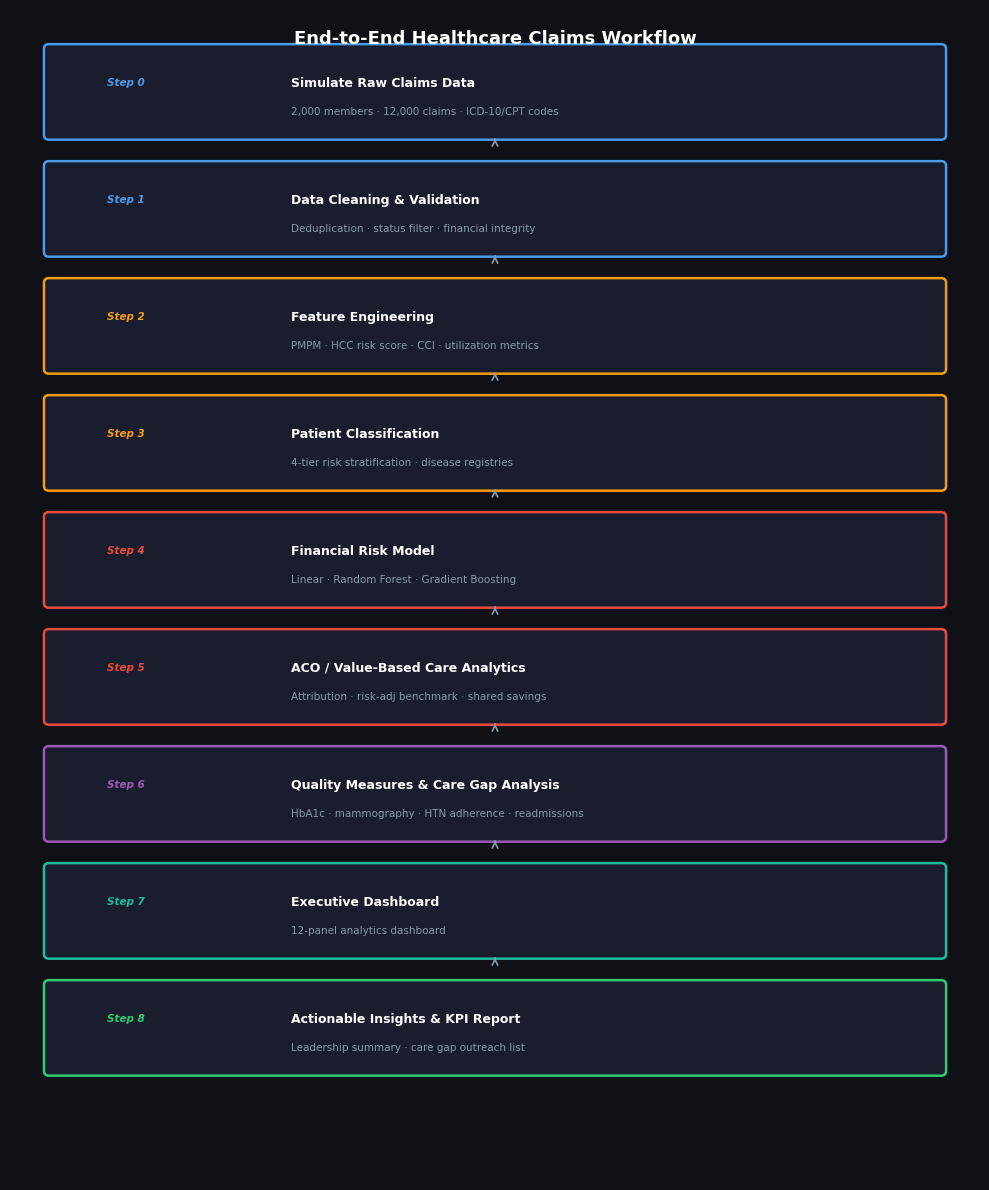

Workflow diagram saved to workflow_diagram.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 12))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

DARK   = '#0F1117'
PANEL  = '#1A1D2E'
BLUE   = '#4C9BE8'
GREEN  = '#2ECC71'
GOLD   = '#F39C12'
RED    = '#E74C3C'
PURP   = '#9B59B6'
TEAL   = '#1ABC9C'
WHITE  = '#FFFFFF'
GRAY   = '#8899AA'

steps = [
    (11.2, 'Step 0',  'Simulate Raw Claims Data',              '2,000 members · 12,000 claims · ICD-10/CPT codes',    BLUE),
    (10.0, 'Step 1',  'Data Cleaning & Validation',            'Deduplication · status filter · financial integrity',  BLUE),
    ( 8.8, 'Step 2',  'Feature Engineering',                   'PMPM · HCC risk score · CCI · utilization metrics',   GOLD),
    ( 7.6, 'Step 3',  'Patient Classification',                '4-tier risk stratification · disease registries',      GOLD),
    ( 6.4, 'Step 4',  'Financial Risk Model',                  'Linear · Random Forest · Gradient Boosting',           RED),
    ( 5.2, 'Step 5',  'ACO / Value-Based Care Analytics',      'Attribution · risk-adj benchmark · shared savings',    RED),
    ( 4.0, 'Step 6',  'Quality Measures & Care Gap Analysis',  'HbA1c · mammography · HTN adherence · readmissions',  PURP),
    ( 2.8, 'Step 7',  'Executive Dashboard',                   '12-panel analytics dashboard',                         TEAL),
    ( 1.6, 'Step 8',  'Actionable Insights & KPI Report',      'Leadership summary · care gap outreach list',          GREEN),
]

ax.text(5, 11.7, 'End-to-End Healthcare Claims Workflow',
        ha='center', va='center', fontsize=13, fontweight='bold', color=WHITE)

for y, label, title, subtitle, color in steps:
    box = mpatches.FancyBboxPatch(
        (0.4, y - 0.48), 9.2, 0.88,
        boxstyle='round,pad=0.05',
        facecolor=PANEL, edgecolor=color, linewidth=1.8)
    ax.add_patch(box)

    ax.text(1.0, y + 0.05, label, ha='left', va='center',
            fontsize=7.5, color=color, fontweight='bold', fontstyle='italic')
    ax.text(2.9, y + 0.05, title, ha='left', va='center',
            fontsize=9, color=WHITE, fontweight='bold')
    ax.text(2.9, y - 0.25, subtitle, ha='left', va='center',
            fontsize=7.5, color=GRAY)

    if y > 1.6:
        ax.annotate('', xy=(5, y - 0.52), xytext=(5, y - 0.48 - 0.05),
                    arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.2))

plt.tight_layout()
plt.savefig('workflow_diagram.png', dpi=140, bbox_inches='tight', facecolor=DARK)
plt.show()
print('Workflow diagram saved to workflow_diagram.png')

---

## Open the Notebooks

Click the links below (when running in Jupyter) to open each part:

- **[Part 1 - Patient Classification Tools](01_patient_classification_tools.ipynb)**  
  *Start here to understand the coding systems and classification tools used throughout.*

- **[Part 2 - Data Scientist Responsibilities](02_ds_responsibilities_claims_classification.ipynb)**  
  *Understand the full scope of the DS role before writing code.*

- **[Part 3 - End-to-End Healthcare Claims Workflow](03_healthcare_claims_workflow.ipynb)**  
  *Implement the complete pipeline in Python — from raw claims to executive dashboard.*

---

> **Note:** All data is synthetically generated. No real patient information is used.